<div style="text-align: center; margin-top: 80px;">

# **Universidad Internacional de la Rioja (UNIR)**

## Escuela Superior de Ingeniería y Tecnología
## Máster en Computación Cuántica

## Prácticas de empresa
# **[Título]**


### Presentada por: Jon Zapata Muñoz

#### Fecha: Agosto de 2026  

---

</div>

## **Introducción**
El objetivo de este Notebook es crear una aplicación que genere mapas de ruido bidimensionales, aleatorios pero suaves y similares al ruido Perlin utilizando una técnica quantum-inspired basada en redes tensoriales de tipo PEPS (Projected Entangled Pair States) y una arquitectura entrenable.

El código se compone de una clase denominada GenerativePEPS cuyas funciones miembro implementan dicha aplicación. Estas funciones incluyen:
- __init__: el constructor de la clase. Recibe los parámetros necesarios para generar la red tensorial.
- __ContractPEPS__: Aplica las contracciones a la red tensorial para generar el mapa de ruido. Aún está en proceso.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [28]:
class GenerativePEPS(nn.Module):
    def __init__(self, N, D, p, use_torch = False, rng = None):
        """
        Constructor de la clase. Dados una serie de parámetros, genera
        la red tensorial inicial y guarda dichos parámetros para poder generar 
        el mapa de ruido correctamente
        N: La dimensión en píxeles de la imagen resultante
        D: la dimensión de lazo entre los tensores que componen la red tensorial. En esencia, esto representa cuántos
        valores puede tener cada índice. Esto ayuda a generar más suavidad, dando más correlación entre los tensores.
        p: la dimensión física
        use_torch: [temporal] variable para dictaminar si usamos numpy o torch
        rng: un generador de números aleatorios para generar la red tensorial inicial.
        """
        super().__init__()
        self.N = N;
        self.D = D;
        self.p = p;
        self.use_torch = use_torch;
        if rng is None:
            rng = np.random.default_rng()
        if(use_torch == True):
            self.tensors = nn.Parameter(torch.rand(N, N, D, D, D, D, p) * 0.1) 
        else: 
            self.tensors = rng.standard_normal((N, N, D, D, D, D, p)) * 0.1
        
        print(f"params per tensor: {D**4 * p}")
        print(f"total params:      {N * N * D**4 * p}")
        
    def forward(self):
        """
        El algoritmo principal de la clase. Genera el mapa de ruido utilizando una red
        tensorial PEPS
        """
        boundary = [torch.ones(self.D, device=self.tensors.device) / self.D for _ in range(self.N)]
        
        noise_map_rows = []

        for row in range(self.N):
            left_vec = torch.zeros(self.D, device=self.tensors.device)
            left_vec[0] = 1.0
            
            current_row_scalars = []
            next_boundary = []

            for col in range(self.N):
                T = self.tensors[row, col]  # Shape: (D, D, D, D, p)
                up_vec = boundary[col]      # Shape: (D,)

                # Contract bonds safely
                out_rd = torch.einsum('lrud...,l,u->rd...', T, left_vec, up_vec)
                out_rd = out_rd.squeeze(-1) # Shape: (D, D)
                
                # Out-of-place: Collect the scalar into a list
                current_row_scalars.append(out_rd[0, 0])

                # Get downstream vectors
                new_right = torch.sum(out_rd, dim=1)
                new_down = torch.sum(out_rd, dim=0)

                # Normalize (Creates fresh, new tensors out-of-place)
                left_vec = new_right / (torch.norm(new_right) + 1e-8)
                normalized_down = new_down / (torch.norm(new_down) + 1e-8)
                
                # Queue the updated boundary vector for the NEXT row
                next_boundary.append(normalized_down)

            # Move to the next row: swap the boundary reference completely
            boundary = next_boundary
            
            # Stack this row's list of scalars into a 1D tensor
            noise_map_rows.append(torch.stack(current_row_scalars))

        # Stack all row tensors into the final 2D noise map
        noise_map = torch.stack(noise_map_rows)
        return noise_map
        
    def ContractPEPSNumpy(self):
        """
        El algoritmo principal de la clase. Genera el mapa de ruido utilizando una red
        tensorial PEPS
        """
        noise_map = np.zeros((self.N, self.N))
    
        # Inicializamos la frontera superior: un vector de D dimensiones por columna
        boundary = np.ones((self.N, self.D)) / self.D

        
        for row in range(N):
            #por cada fila, una nueva frontera a la izquierda vacía
            left_vec = np.zeros(self.D)
            left_vec[0] = 1.0
    
            for col in range(N):
                T = self.tensors[row, col]        # Shape: (D, D, D, D, p)
                up_vec = boundary[col]       # Shape: (D,)
    
                # Contraemos los vectores de arriba y de la izquierda de forma simultánea.
                # l: left, r: right, u: up, d: down
                # El resultado será una matriz de dimensiones (r, d) que contiene los vectores right y down (sin normalizar) 
                # emparejados.
                out_rd = np.einsum('lrud,l,u->rd', T[..., 0], left_vec, up_vec)
                
                # RGuardamos el valor del mapa (e.g., r=0, d=0)
                noise_map[row, col] = out_rd[0, 0]
    
                # Desparejamos el resutlado (r, d) , moviéndolos a vectores right y down separados.
                # De momento, lo hacemos así.
                new_right = np.sum(out_rd, axis=1) # Sum out 'd' to get 'r'
                new_down = np.sum(out_rd, axis=0)  # Sum out 'r' to get 'd'
    
                # Normalizamos y pasamos al siguiente vector
                left_vec = new_right / (np.linalg.norm(new_right) + 1e-10)
                boundary[col] = new_down / (np.linalg.norm(new_down) + 1e-10)
    
        return noise_map

params per tensor: 16
total params:      6400


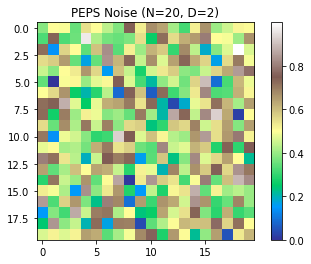

In [29]:
N = 20
D = 2
p = 1
rng = np.random.default_rng(36)
peps = GenerativePEPS(N, D, p, False, rng)

# Now uses the inferred N and D safely
raw_map = peps.ContractPEPSNumpy()

display_map = (raw_map - raw_map.min()) / (raw_map.max() - raw_map.min() + 1e-10)
plt.imshow(display_map, cmap='terrain')
plt.colorbar()
plt.title(f"PEPS Noise (N={N}, D={D})")
plt.show()

params per tensor: 16
total params:      6400
Epoch 0 | Loss: 0.0645 | TV: 0.0649
Epoch 50 | Loss: 0.0051 | TV: 0.0051
Epoch 100 | Loss: 0.0046 | TV: 0.0046
Epoch 150 | Loss: 0.0045 | TV: 0.0045


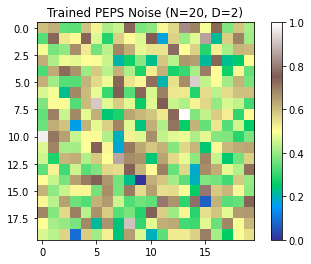

In [30]:
model = GenerativePEPS(N, D, p, True, rng)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- Training Loop ---
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Generate the noise map
    generated_map = model()
    
    # 1. Total Variation Loss (Forces Smoothness)
    # Penalizes differences between adjacent pixels (rows and cols)
    diff_h = torch.abs(generated_map[:, 1:] - generated_map[:, :-1]).mean()
    diff_v = torch.abs(generated_map[1:, :] - generated_map[:-1, :]).mean()
    tv_loss = diff_h + diff_v
    
    # 2. Variance Loss (Prevents the map from just turning entirely flat/gray)
    # We want it smooth, but we still want hills and valleys!
    var_loss = -torch.var(generated_map) 
    
    # Total loss: balance smoothness against feature contrast
    loss = tv_loss + (0.5 * var_loss)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | TV: {tv_loss.item():.4f}")

# --- Visualization ---
with torch.no_grad():
    final_map = model()
    # Normalize for display
    display_map = (final_map - final_map.min()) / (final_map.max() - final_map.min())

plt.imshow(display_map.numpy(), cmap='terrain')
plt.colorbar()
plt.title(f"Trained PEPS Noise (N={N}, D={D})")
plt.show()